### Connect to Github, Google Drive, Kaggle
When you connect to external services like Github, Google Drive, or Kaggle, you can easily access and manage your files, datasets, and repositories directly from your development environment. This integration allows for seamless collaboration, version control, and data management.

When asked, you have to provide an active token to connect to Github.

In [4]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")     # Digit your Github token and press enter.
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [5]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

At this point, you will downlaod the dataset from Kaggle.

In [6]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


For later use, install yt-dlp, which is a feature-rich command-line audio/video downloader.

In [7]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.0 MB/s eta 0:00:00:00:01


Import all necessary libraries and modules for the project. This includes standard libraries, third-party packages, and custom modules that are required for the implementation of the Unified Lifelong Action Learning (ULAL) framework. Initialize the framework by setting up configurations, paths, and any other necessary parameters. Inizialize the random seed for reproducibility of results across different runs of the code.

In [8]:
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Setup (30 classes)**

__cfg.SELECTED_CLASSES__ contains the base classes used for training the model. For every new task, select other 10 different classes from the remaining 70 classes. The model will be trained on these new classes while retaining knowledge of the previously learned classes.

In [9]:
cfg.TASK_1 = ["ApplyEyeMakeup", "ApplyLipstick", "Archery", "BabyCrawling", "BalanceBeam",
              "BandMarching", "BlowDryHair", "BlowingCandles", "BodyWeightSquats", "Bowling"]
cfg.TASK_2 = ["BoxingPunchingBag", "BoxingSpeedBag", "BrushingTeeth", "CliffDiving", "CricketBowling",
              "CricketShot", "CuttingInKitchen", "FieldHockeyPenalty", "Haircut", "SoccerPenalty"]

**ALL_CLASSES_LIST** contains all the classes used.

In [10]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {name: i for i, name in enumerate(ALL_CLASSES_LIST)}
n_base = len(cfg.SELECTED_CLASSES)   # 10 base
n_t1   = len(cfg.TASK_1)             # 10 new in task 1
n_t2   = len(cfg.TASK_2)             # 10 new in task 2
print(f"base {n_base}  task1 {n_t1}  task2 {n_t2}  total {len(ALL_CLASSES_LIST)}")

base 10  task1 10  task2 10  total 30


## **Preprocess data**

Preprocess the data by doing a group split of the videos into clips. This ensures that one group of source videos never leaks across train and test datasets, maintaining the integrity of the training and evaluation process. After that the data is preprocessed and split into training and testing sets for the base model and subsequent tasks. The preprocessing step includes converting videos into clips, ensuring that the data is organized and ready for model training and evaluation.

In [11]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [12]:
preprocess_group_split(base_split,  cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT,  max_samples=cfg.MAX_SAMPLES)
preprocess_group_split(task1_split, cfg.TASK_1,           output_root=cfg.TASK1_ROOT, max_samples=cfg.MAX_SAMPLES)
preprocess_group_split(task2_split, cfg.TASK_2,           output_root=cfg.TASK2_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


## **Create Loaders**

Create dataset and dataloaders for every task. The dataloaders are responsible for efficiently loading the data in batches during training and evaluation, allowing for better memory management and faster processing. Create a combined test loader that contains all the classes seen so far (base + task1 + task2).

In [13]:
base_train  = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "train"), class_to_idx=class_to_idx)
base_val    = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "val"),   class_to_idx=class_to_idx)
base_test   = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx)
task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

base_train_loader  = DataLoader(base_train,  batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
base_test_loader   = DataLoader(base_test,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

# Combine into a single test laoder that contains all the classes seen so far (base + task1 + task2)
combined_test_loader2 = DataLoader(ConcatDataset([base_test, task1_test, task2_test]), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
print(f"base {len(base_train)}/{len(base_test)}  task1 {len(task1_train)}/{len(task1_test)}  task2 {len(task2_train)}/{len(task2_test)}")

base 953/212  task1 936/217  task2 991/226


## **Part 1: Upload the base model (ResNet50, 10 classes)**

Load the ResNet50 model that was already trained on the 10 base classes. This is the teacher for the next steps. Test it on the base classes to check it works and print the confusion matrix.

In [14]:
teacher = ResNet50LSTM(num_classes=n_base).to(device)
teacher.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
teacher.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s] 


ResNet50LSTM(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

Test Accuracy: 0.9387


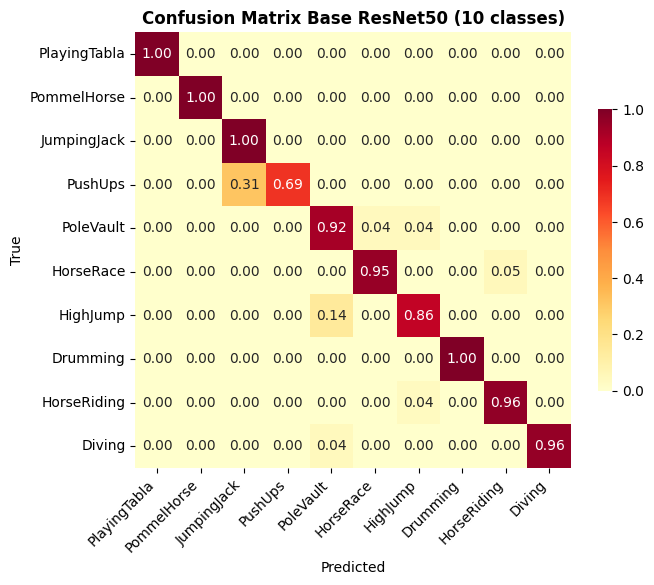

In [15]:
#0.9387
base_acc, base_preds, base_labels = test_model(teacher, base_test_loader, device)
plot_confusion_matrix(base_labels, base_preds, num_classes=n_base,
                      classes_list=cfg.SELECTED_CLASSES, name="Base ResNet50 (10 classes)")

## **Part 2: Continual learning with replay**

Add new classes step by step: 10 to 20 to 30. Keep a small buffer of old clips and mix them into every new batch. Replay was the best method in the continual learning study. Plot the same charts as the CL notebook: training curves, confusion matrix, old vs new accuracy, and the forgetting curve.

In [ ]:
# the continual model starts from the base teacher
model = unfreeze_all(teacher).to(device)
forget_hist = []

# buffer of old clips: 15 base clips per class (big enough for base + task 1 later)
buffer = ReplayBuffer(max_size=600)
fill_buffer(buffer, base_train_loader, per_class=15)
print(f"buffer: {len(buffer.data)} clips")

buffer: 150 clips


**Task 1**

Add 10 new classes to the base model. Expand the model to accommodate the new classes and train it on the combined dataset of old and new classes. Evaluate the model's performance on both the old and new classes, and visualize the results using confusion matrices and accuracy plots.

To train the model on the new classes, use a replay strategy. This involves maintaining a small buffer of old clips and mixing them into every new batch during training. This helps the model retain knowledge of previously learned classes while learning new ones.

In [ ]:
model = expand_classifier(model, n_base + n_t1) # Grow the head to 20 classes and learn task 1
model = unfreeze_all(model).to(device)

set_seed(cfg.SEED)
track1 = {"Base": base_test_loader, "Task 1": task1_test_loader}
hist_t1 = train_continual(model, task1_train_loader, task1_val_loader, device,     
                          buffer=buffer, num_old_classes=n_base,
                          epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                          track_loaders=track1, track_history=forget_hist)
torch.cuda.empty_cache()

Epoch [1/5] | Train Acc: 0.7922 Loss: 0.8400 | Val Acc: 0.8824 Loss: 0.6314
Epoch [2/5] | Train Acc: 0.9802 Loss: 0.1505 | Val Acc: 0.8889 Loss: 0.4684
Epoch [3/5] | Train Acc: 0.9973 Loss: 0.0460 | Val Acc: 0.9020 Loss: 0.4038
Epoch [4/5] | Train Acc: 0.9968 Loss: 0.0272 | Val Acc: 0.8824 Loss: 0.3817
Epoch [5/5] | Train Acc: 0.9957 Loss: 0.0386 | Val Acc: 0.8562 Loss: 0.4906


Loss and accuracy curves are plotted to visualize the training process on task 1 using replay method.

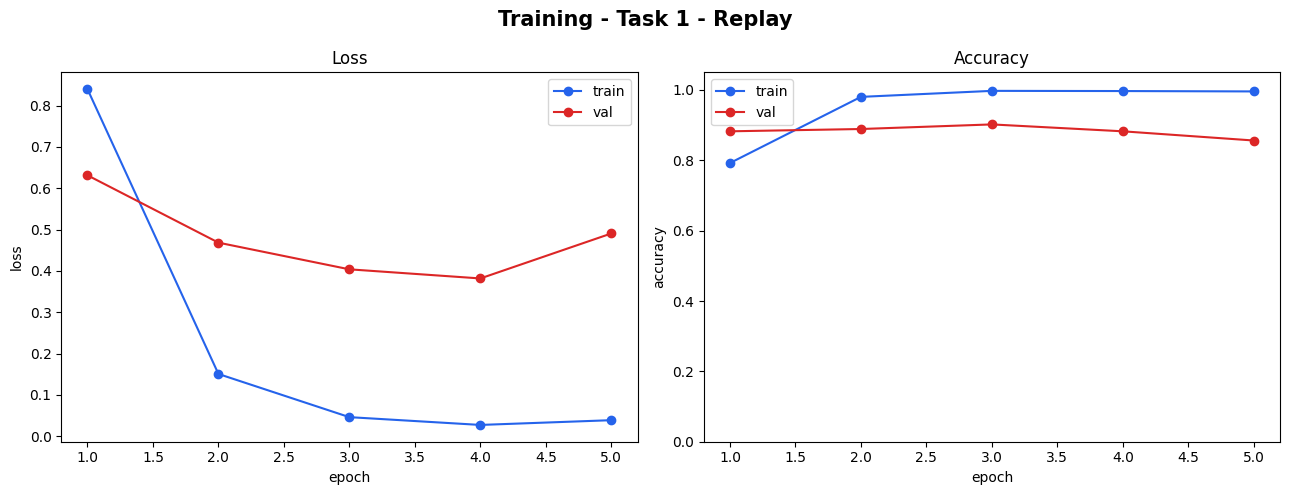

In [ ]:
plot_training_results(hist_t1, task_name="Task 1 - Replay")

**Task 2**

Add 10 more new classes to the model. Now the model has been expanded to a total of 30 classes. Train the model and evaluate its performance like in task1 with confusion matrices and accuracy plots.

The buffer is updated with new clips of task1 dataset.

In [ ]:
# add task 1 clips to the buffer, then grow to 30 and learn task 2
fill_buffer(buffer, task1_train_loader, per_class=15)
model = expand_classifier(model, n_base + n_t1 + n_t2)
model = unfreeze_all(model).to(device)

set_seed(cfg.SEED)
track2 = {"Base": base_test_loader, "Task 1": task1_test_loader, "Task 2": task2_test_loader}
hist_t2 = train_continual(model, task2_train_loader, task2_val_loader, device,
                          buffer=buffer, num_old_classes=n_base + n_t1,
                          epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                          track_loaders=track2, track_history=forget_hist)
torch.cuda.empty_cache()

Epoch [1/5] | Train Acc: 0.7639 Loss: 0.9861 | Val Acc: 0.8038 Loss: 0.9048
Epoch [2/5] | Train Acc: 0.9677 Loss: 0.2319 | Val Acc: 0.8228 Loss: 0.5564
Epoch [3/5] | Train Acc: 0.9914 Loss: 0.0811 | Val Acc: 0.8544 Loss: 0.5441
Epoch [4/5] | Train Acc: 0.9934 Loss: 0.0531 | Val Acc: 0.8291 Loss: 0.6579
Epoch [5/5] | Train Acc: 0.9970 Loss: 0.0321 | Val Acc: 0.8481 Loss: 0.6277


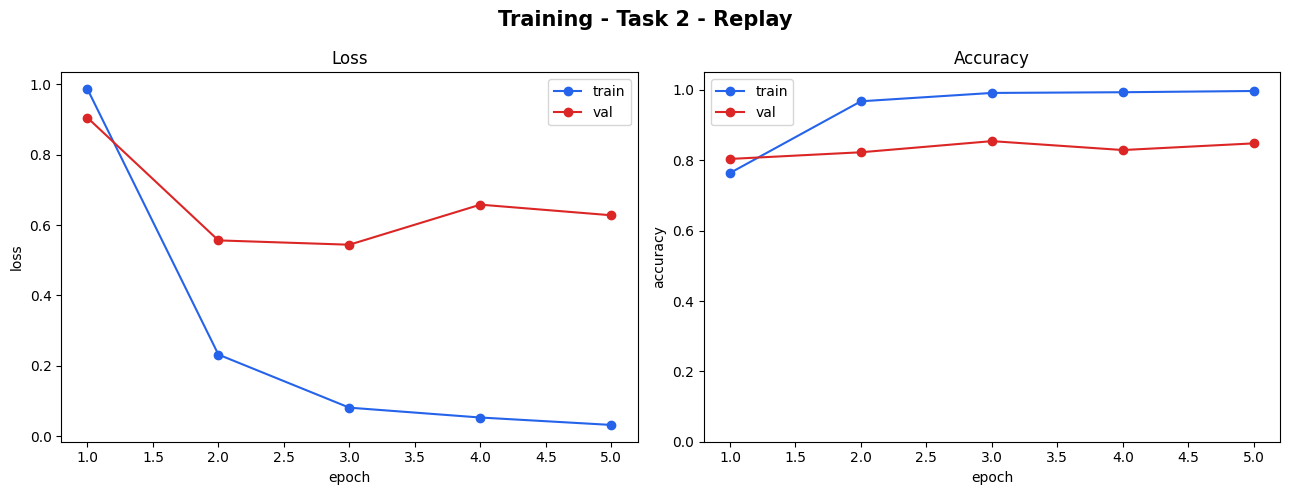

In [ ]:
plot_training_results(hist_t2, task_name="Task 2 - Replay")

Test the model on the final combined test set that contains all classes seen. 

Plot the forgetting curve to visualize how the model retains knowledge of previously learned classes while learning new ones.

Test Accuracy: 0.7969


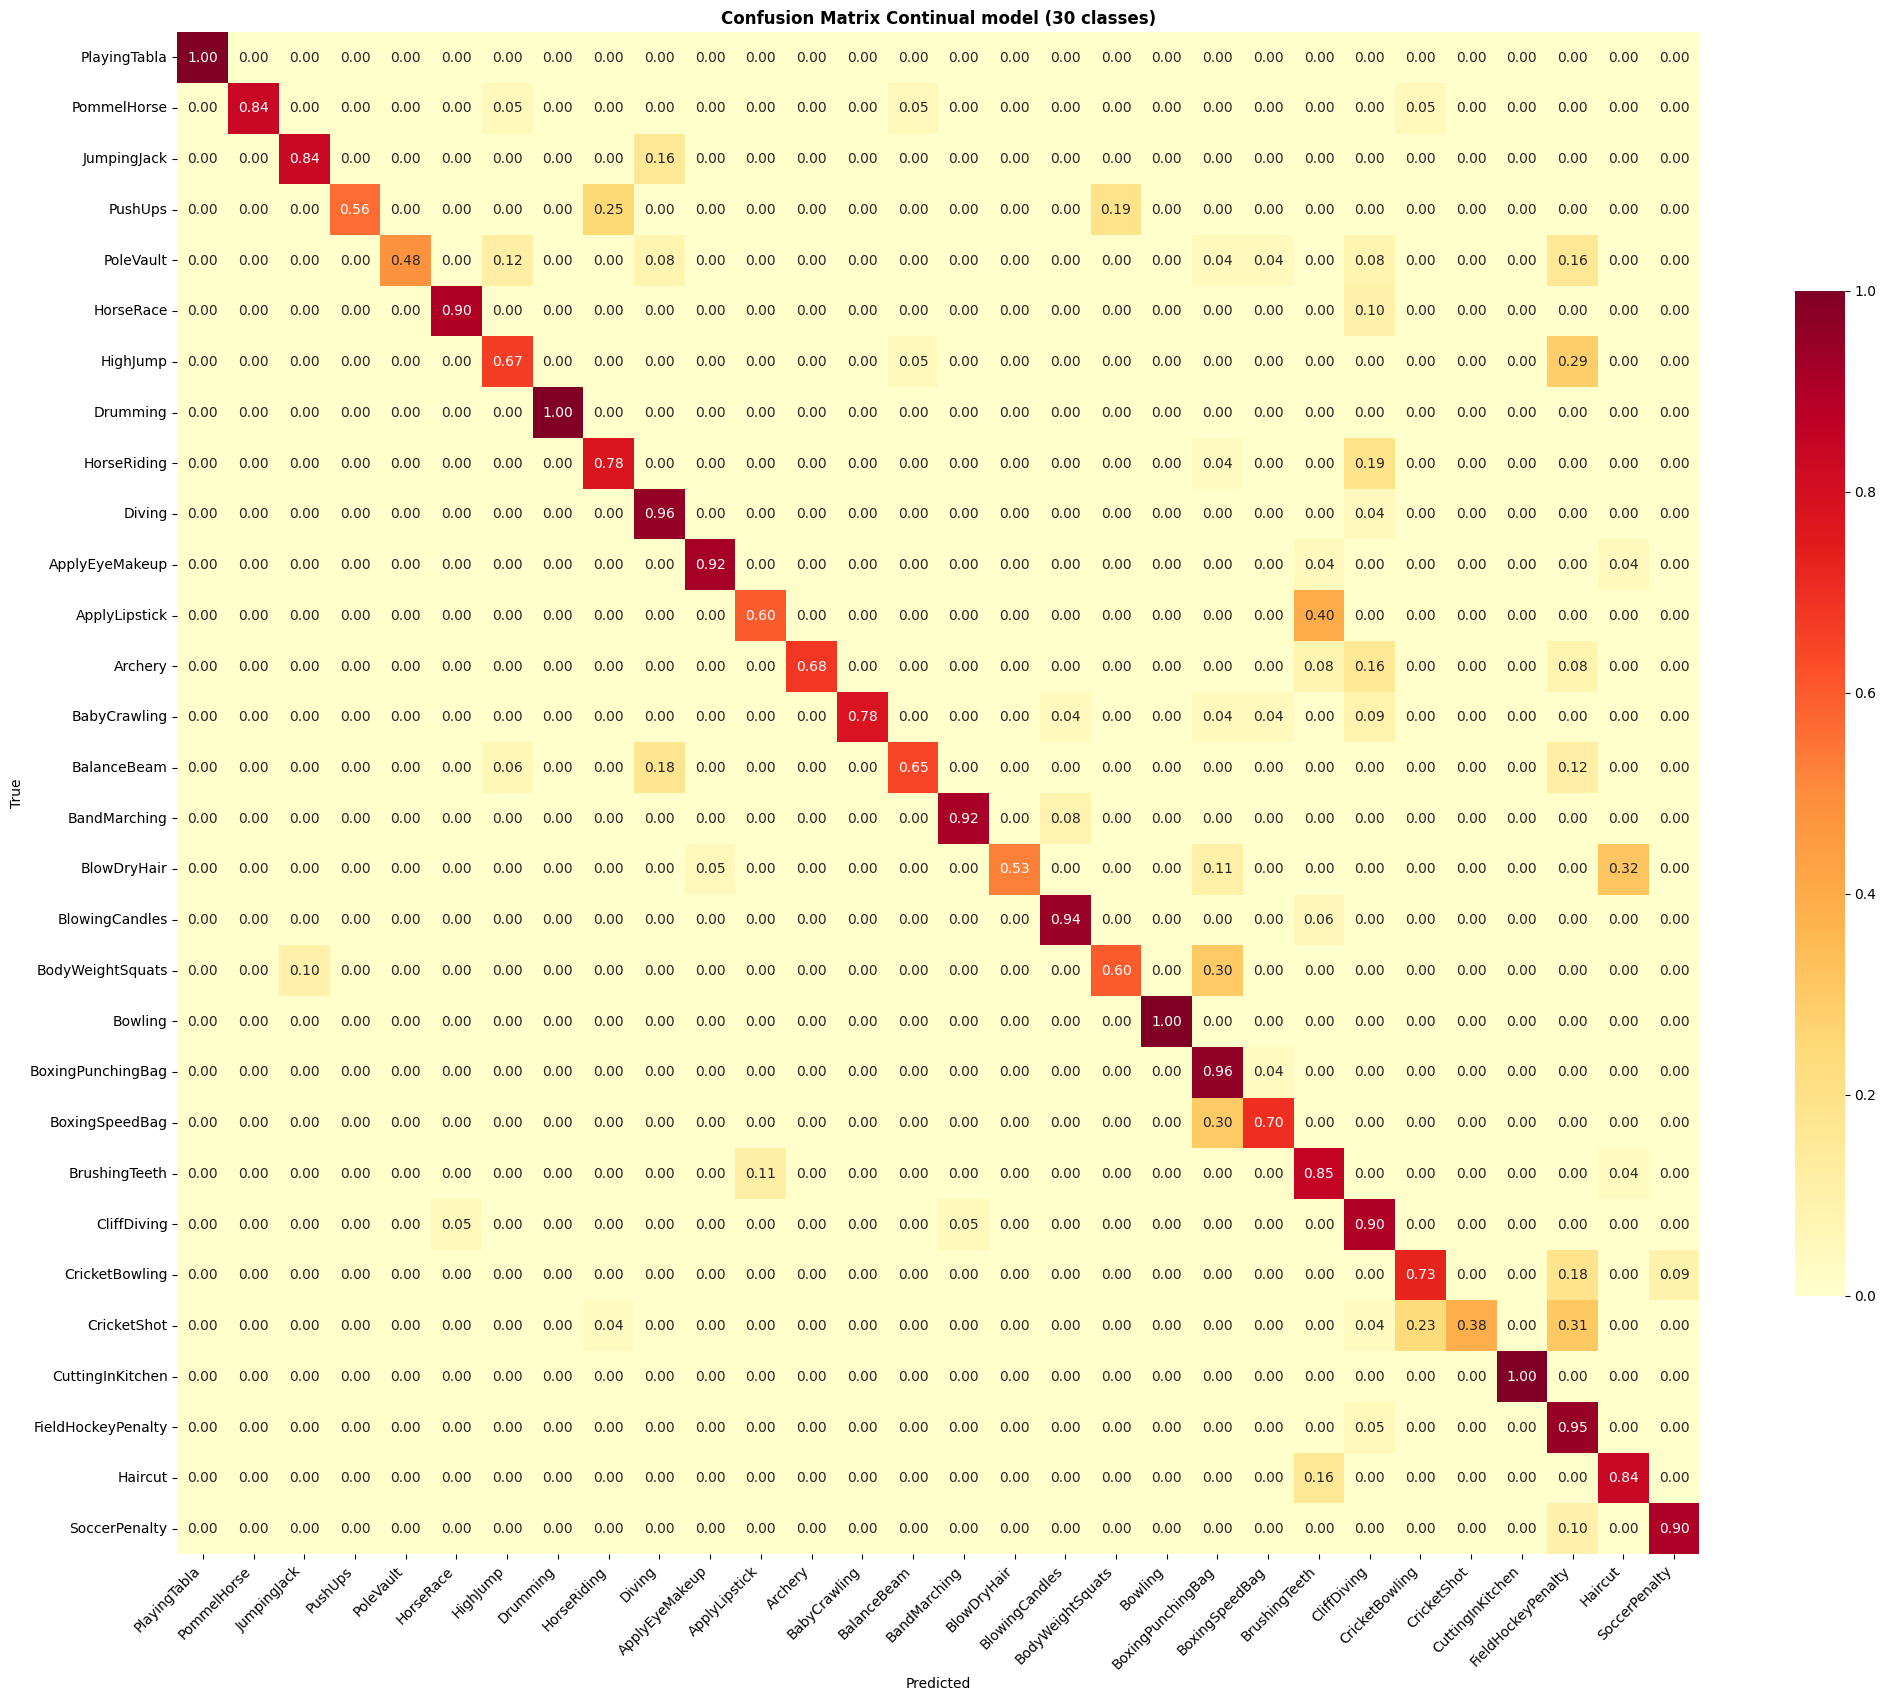

In [18]:
# test the final continual model on all 30 classes
cl_acc, cl_preds, cl_labels = test_model(model, combined_test_loader2, device)
plot_confusion_matrix(cl_labels, cl_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Continual model (30 classes)")

In [ ]:
# old vs new accuracy, like the CL notebook
split_at = n_base + n_t1
print_detailed_metrics(cl_labels, cl_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, split_at), split_new=(split_at, len(ALL_CLASSES_LIST)))


METRICS FOR 30 CLASSES
  Accuracy : 0.7969
  F1-Score : 0.7993

PER-CLASS REPORT
                    precision    recall  f1-score   support

      PlayingTabla       1.00      1.00      1.00        17
       PommelHorse       1.00      0.84      0.91        19
       JumpingJack       0.89      0.84      0.86        19
           PushUps       1.00      0.56      0.72        16
         PoleVault       1.00      0.48      0.65        25
         HorseRace       0.95      0.90      0.92        20
          HighJump       0.74      0.67      0.70        21
          Drumming       1.00      1.00      1.00        25
       HorseRiding       0.81      0.78      0.79        27
            Diving       0.73      0.96      0.83        23
    ApplyEyeMakeup       0.96      0.92      0.94        25
     ApplyLipstick       0.80      0.60      0.69        20
           Archery       1.00      0.68      0.81        25
      BabyCrawling       1.00      0.78      0.88        23
       BalanceBea

Visualize the forgetting curve for each task based on accuracy over the whole training process.

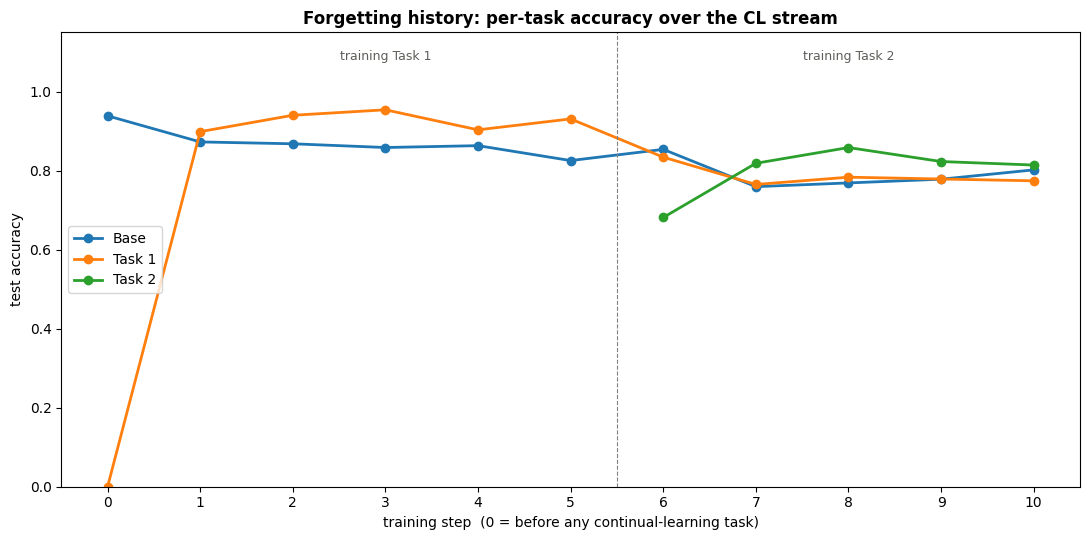

In [ ]:
plot_forgetting_history(forget_hist, epochs_per_task=cfg.CL_EPOCHS)

In [ ]:
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
torch.save(model.state_dict(), f"{cfg.CKPT_DIR}/teacher_30.pt")
print(f"saved model -> {cfg.CKPT_DIR}/teacher_30.pt")

saved model -> /content/drive/MyDrive/apai/checkpoints/teacher_30.pt


## **Part 3: Knowledge distillation (cosine)**

Copy the big 30 class continual model into a small MobileNet student. Use cosine distillation, the best method in the distillation study. Plot the training curve and the confusion matrix, like the distillation notebook.

Create a combined dataloader of the previous tasks.

In [17]:
n_base = 30

model = ResNet50LSTM(num_classes=n_base).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/apai/checkpoints/teacher_30.pt", map_location=device))

<All keys matched successfully>

In [16]:
train_all_loader = DataLoader(ConcatDataset([base_train, task1_train, task2_train]), batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_all_loader   = DataLoader(ConcatDataset([base_val,   task1_val,   task2_val]),   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

Train a student model on all 30 classes at once using knowledge distillation. 

- The teacher model is the previous ResNet50 Model trained on all 30 classes(previous tasks)
- The student model is a smaller MobileNet model that will learn from the teacher model's outputs.

In [ ]:
student = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)
set_seed(cfg.SEED)
student, hist_kd = train_student(student, model, train_all_loader, val_all_loader, device,
                                 mode="cosine", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                 distill_weight=cfg.KD_DISTILL_WEIGHT,
                                 epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 105MB/s]


[cosine] epoch 01/10 | Train Acc: 0.2934 | Val Acc: 0.5042
[cosine] epoch 02/10 | Train Acc: 0.5951 | Val Acc: 0.6807
[cosine] epoch 03/10 | Train Acc: 0.7219 | Val Acc: 0.6534
[cosine] epoch 04/10 | Train Acc: 0.7934 | Val Acc: 0.6849
[cosine] epoch 05/10 | Train Acc: 0.8372 | Val Acc: 0.7311
[cosine] epoch 06/10 | Train Acc: 0.8743 | Val Acc: 0.6912
[cosine] epoch 07/10 | Train Acc: 0.9049 | Val Acc: 0.7101
[cosine] epoch 08/10 | Train Acc: 0.9101 | Val Acc: 0.7290
[cosine] epoch 09/10 | Train Acc: 0.9240 | Val Acc: 0.7059
[cosine] epoch 10/10 | Train Acc: 0.9306 | Val Acc: 0.7059
  best [cosine] val 0.7311


Plot the training curve for the student model after training.

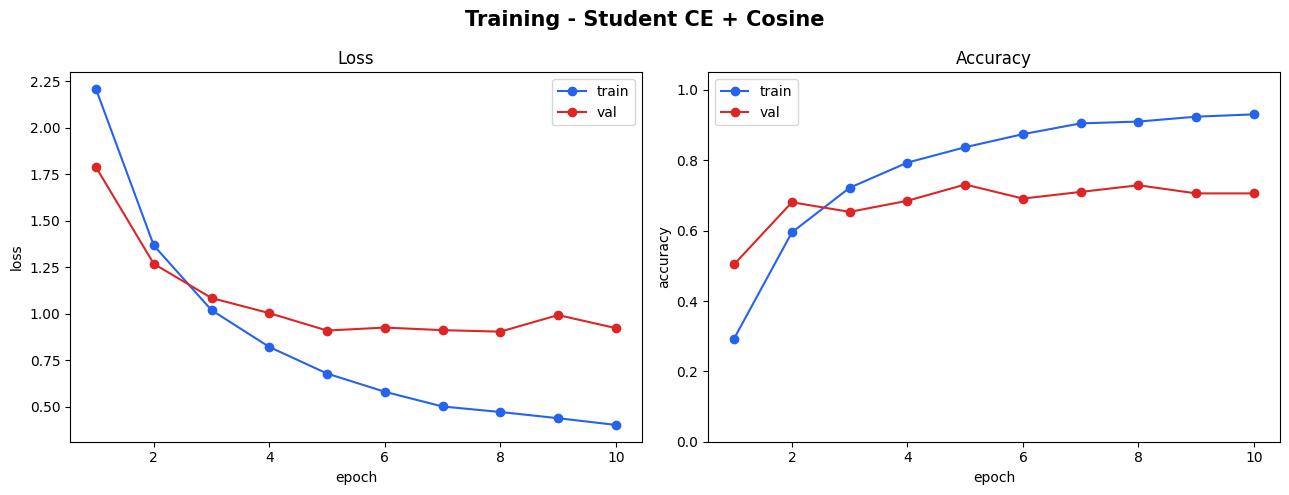

In [25]:
plot_training_results(hist_kd, task_name="Student CE + Cosine")

Plot the confusion matrix for the student model after training.

Test Accuracy: 0.6718


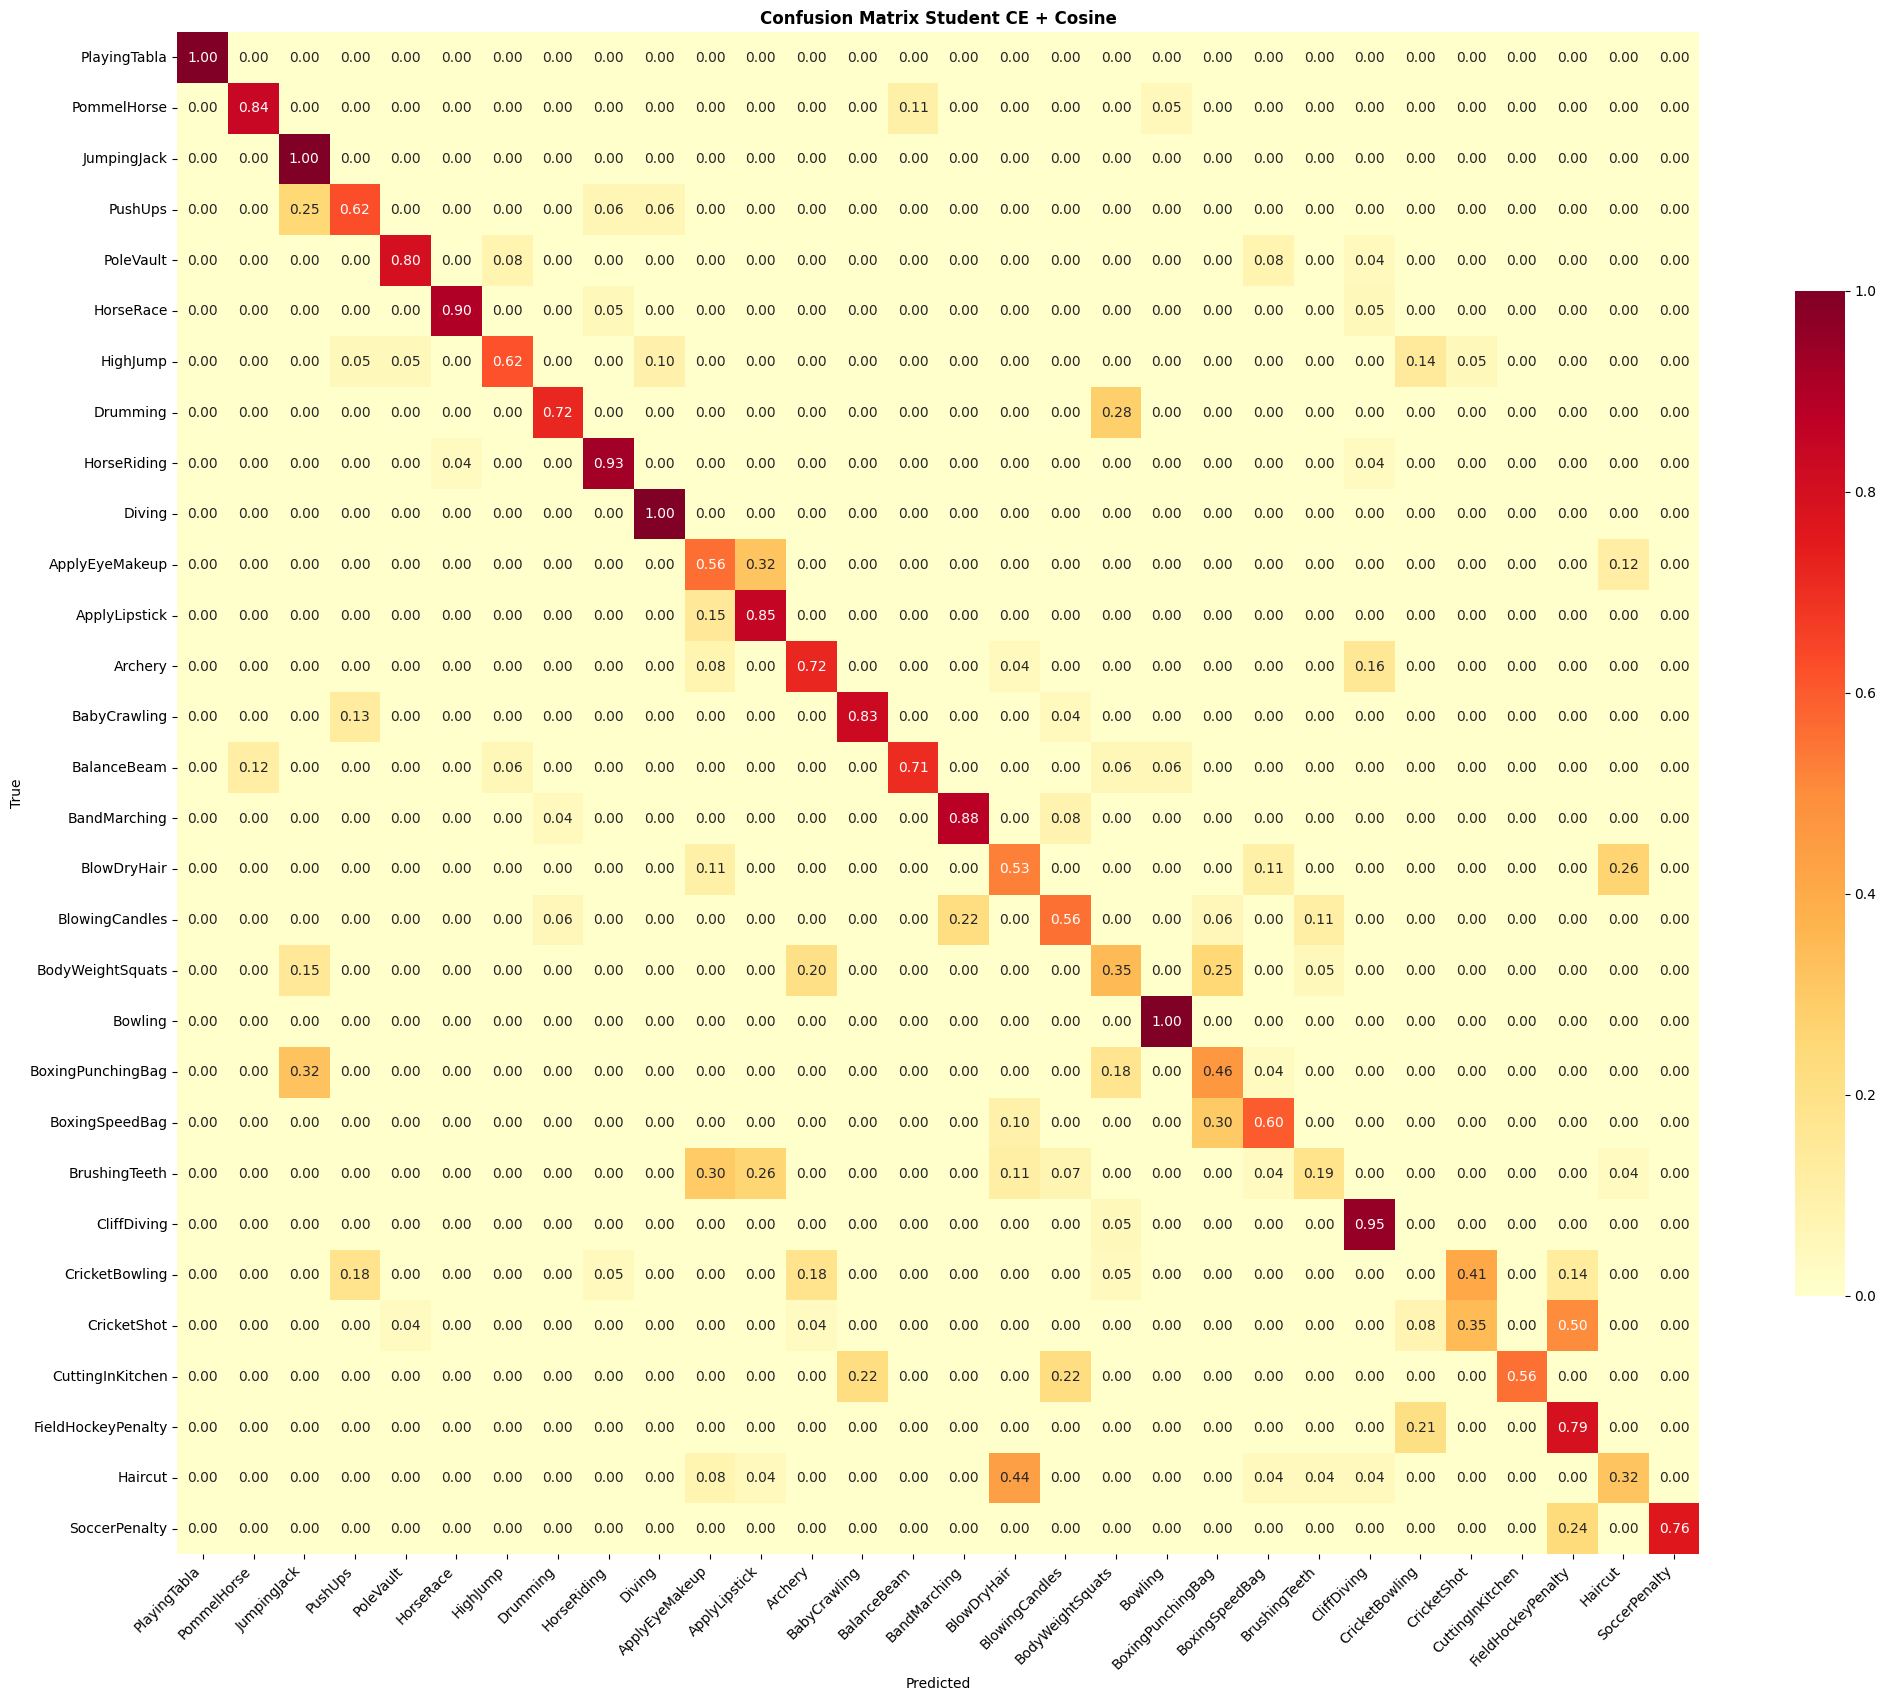

In [19]:
student_acc, student_preds, student_labels = test_model(student, combined_test_loader2, device)
plot_confusion_matrix(student_labels, student_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Student CE + Cosine")

Compare how many parameters the two models have.

In [37]:
# how much smaller is the student
teacher_params = sum(p.numel() for p in model.parameters())
student_params = sum(p.numel() for p in student.parameters())
print(f"continual model : {cl_acc:.4f}  ({teacher_params/1e6:.1f}M params)")
print(f"student (cosine): {student_acc:.4f}  ({student_params/1e6:.1f}M params, {teacher_params/student_params:.0f}x smaller)")

continual model : 0.7969  (25.9M params)
student (cosine): 0.6718  (1.8M params, 14x smaller)


In [28]:
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
torch.save(student.state_dict(), f"{cfg.CKPT_DIR}/student_30.pt")
print(f"saved model -> {cfg.CKPT_DIR}/student_30.pt")

saved model -> /content/drive/MyDrive/apai/checkpoints/student_30.pt


## **Part 4: Few-shot learning (MAML)**

Teach the small student to learn a new class from only a few clips with meta-learning (first-order MAML) on new sports, then re-fit the 30 class head. Same settings as the MAML study notebook: every sport of the meta list that the model does not know (35 sports), 12 clips per sport, and the head is re-fit on 12 clips per known class.

Two changes on top of the study: (1) each meta clip comes from a different source video, so in every episode the query clips come from other videos than the support clips - the same situation as the YouTube test in Part 5 (learn from some videos, recognise the sport in a new one); (2) episodes use 5 support clips per sport (the study used 3), so MAML practises the 5-clip case that Part 5 tests. Part 5 uses this student to learn new sports from a few YouTube clips.

In [16]:
n_base = 30

student = MobileNetV3SmallLSTMStudent(num_classes=n_base).to(device)
student.load_state_dict(torch.load("/content/drive/MyDrive/apai/checkpoints/student_30.pt", map_location=device))

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 87.3MB/s]


<All keys matched successfully>

In [20]:
torch.cuda.empty_cache(); gc.collect() # empty the GPU cache and collect garbage to free up memory for meta-learning

# same settings as the MAML study notebook
N_WAY = 5; K_SHOT = 5; K_QUERY = 3   # 5-shot episodes to match the 5-clip YouTube test (the study used 3)
META_EPOCHS = 8; META_EPISODES = 60
INNER_STEPS = 5; META_INNER_LR = 0.05; META_LR = 1e-4
META_TRAIN_LAST = 4
HEAD_RECAL_EPOCHS = 3; HEAD_RECAL_LR = 1e-3
POOL_PER_CLASS = 8   # K_SHOT + K_QUERY clips per sport
META_CLIPS  = 12   # clips per meta sport (the study's TRAIN_CAP)
RECAL_CLIPS = 12   # clips per known class for the head re-fit (the study re-fits on its 12-clip base set)

# every meta sport that is not among the 30 known classes
known     = set(ALL_CLASSES_LIST)
MAML_META = [c for c in cfg.SPORTS_META if c not in known]
maml_c2i  = {c: i for i, c in enumerate(ALL_CLASSES_LIST + MAML_META)}

# one clip per source video, so support and query clips never come from the same video (meta val/test are not used)
ULAL_META_ROOT = f"{cfg.DATA_ROOT}/grouped_ulal_meta_pervideo"
meta_split = one_video_per_group(build_group_split(MAML_META, train_groups=18, val_groups=3))
preprocess_group_split(meta_split, MAML_META, output_root=ULAL_META_ROOT, max_samples=META_CLIPS, max_test_samples=1)
meta_train_ds = UCF101Clips(os.path.join(ULAL_META_ROOT, "train"), class_to_idx=maml_c2i)
pool_clips, pool_labels = build_pool([meta_train_ds], per_class=POOL_PER_CLASS)
meta_ids = sorted(set(pool_labels.tolist()))
print(f"meta classes {len(MAML_META)} | pool {tuple(pool_clips.shape)}")
print(f"meta sports: {MAML_META}")


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_ulal_meta_pervideo
Classes: 35 | Train limit: 12

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_ulal_meta_pervideo
meta classes 35 | pool (280, 16, 3, 224, 224)
meta sports: ['BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress', 'Biking', 'Billiards', 'BreastStroke', 'CleanAndJerk', 'Fencing', 'FloorGymnastics', 'FrisbeeCatch', 'HulaHoop', 'IceDancing', 'JavelinThrow', 'JugglingBalls', 'JumpRope', 'Kayaking', 'Lunges', 'Nunchucks', 'ParallelBars', 'PullUps', 'TableTennisShot', 'TennisSwing', 'VolleyballSpiking', 'LongJump', 'Skiing', 'Surfing', 'ThrowDiscus', 'TrampolineJumping', 'SumoWrestling', 'Punch', 'Rafting', 'RockClimbingIndoor', 'RopeClimbing', 'Rowing']


Create a new model for the few-shot learning task. Use the MAML algorithm to train the model on a set of tasks, allowing it to learn how to adapt quickly to new tasks with limited data. After meta-training, recalibrate the model's head to restore the 30-way classification capability.

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


[maml] epoch 1/8 | meta query acc 0.8133
[maml] epoch 2/8 | meta query acc 0.8400
[maml] epoch 3/8 | meta query acc 0.8956
[maml] epoch 4/8 | meta query acc 0.9056
[maml] epoch 5/8 | meta query acc 0.9156
[maml] epoch 6/8 | meta query acc 0.9022
[maml] epoch 7/8 | meta query acc 0.9133
[maml] epoch 8/8 | meta query acc 0.9267


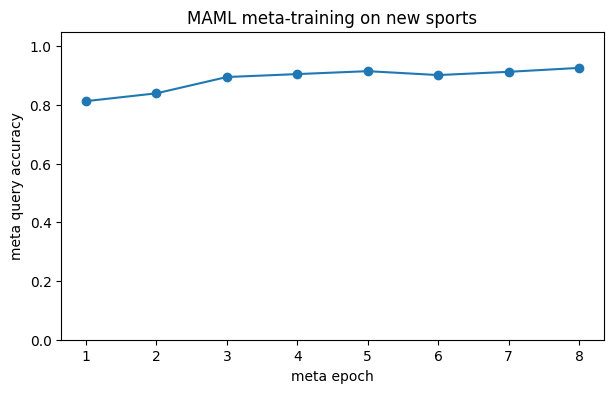

In [21]:
set_seed(cfg.SEED)
maml_student = copy.deepcopy(student)
maml_student.fc = nn.Linear(cfg.HIDDEN_SIZE, N_WAY).to(device)   # throwaway 5-way head for episodes

# meta-train only the last blocks (keep base features)
maml_student, hist_maml = meta_train_maml(maml_student, pool_clips, pool_labels, meta_ids,
                                          N_WAY, K_SHOT, K_QUERY, META_EPOCHS, META_EPISODES,
                                          META_INNER_LR, INNER_STEPS, META_LR, device,
                                          freeze_backbone=True, train_last=META_TRAIN_LAST)
del pool_clips, pool_labels; gc.collect(); torch.cuda.empty_cache()

plt.figure(figsize=(7, 4))
plt.plot(range(1, META_EPOCHS + 1), hist_maml["query_accs"], marker="o")
plt.xlabel("meta epoch"); plt.ylabel("meta query accuracy"); plt.ylim(0, 1.05)
plt.title("MAML meta-training on new sports")
plt.show()

Re-fit the 30-way head to the meta-trained features, on 12 clips per known class like the study (a short linear probe; the backbone and LSTM stay frozen).

In [22]:
set_seed(cfg.SEED)
recal_ds     = ConcatDataset([per_class_subset(base_train, RECAL_CLIPS), per_class_subset(task1_train, RECAL_CLIPS),
                              per_class_subset(task2_train, RECAL_CLIPS)])
recal_loader = DataLoader(recal_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2)
maml_student = recalibrate_head(maml_student, recal_loader, len(ALL_CLASSES_LIST), device,
                                HEAD_RECAL_EPOCHS, HEAD_RECAL_LR)
print(f"head re-fit on {len(recal_ds)} clips ({RECAL_CLIPS} per known class)")

head re-fit on 360 clips (12 per known class)


Plot the confusion matrix after meta-learning and head recalibration. Plot on old dataset to see if the model still remembers the previous classes.

Test Accuracy: 0.6076
MAML student on 30 classes: 0.6076  (KD student was 0.6718)


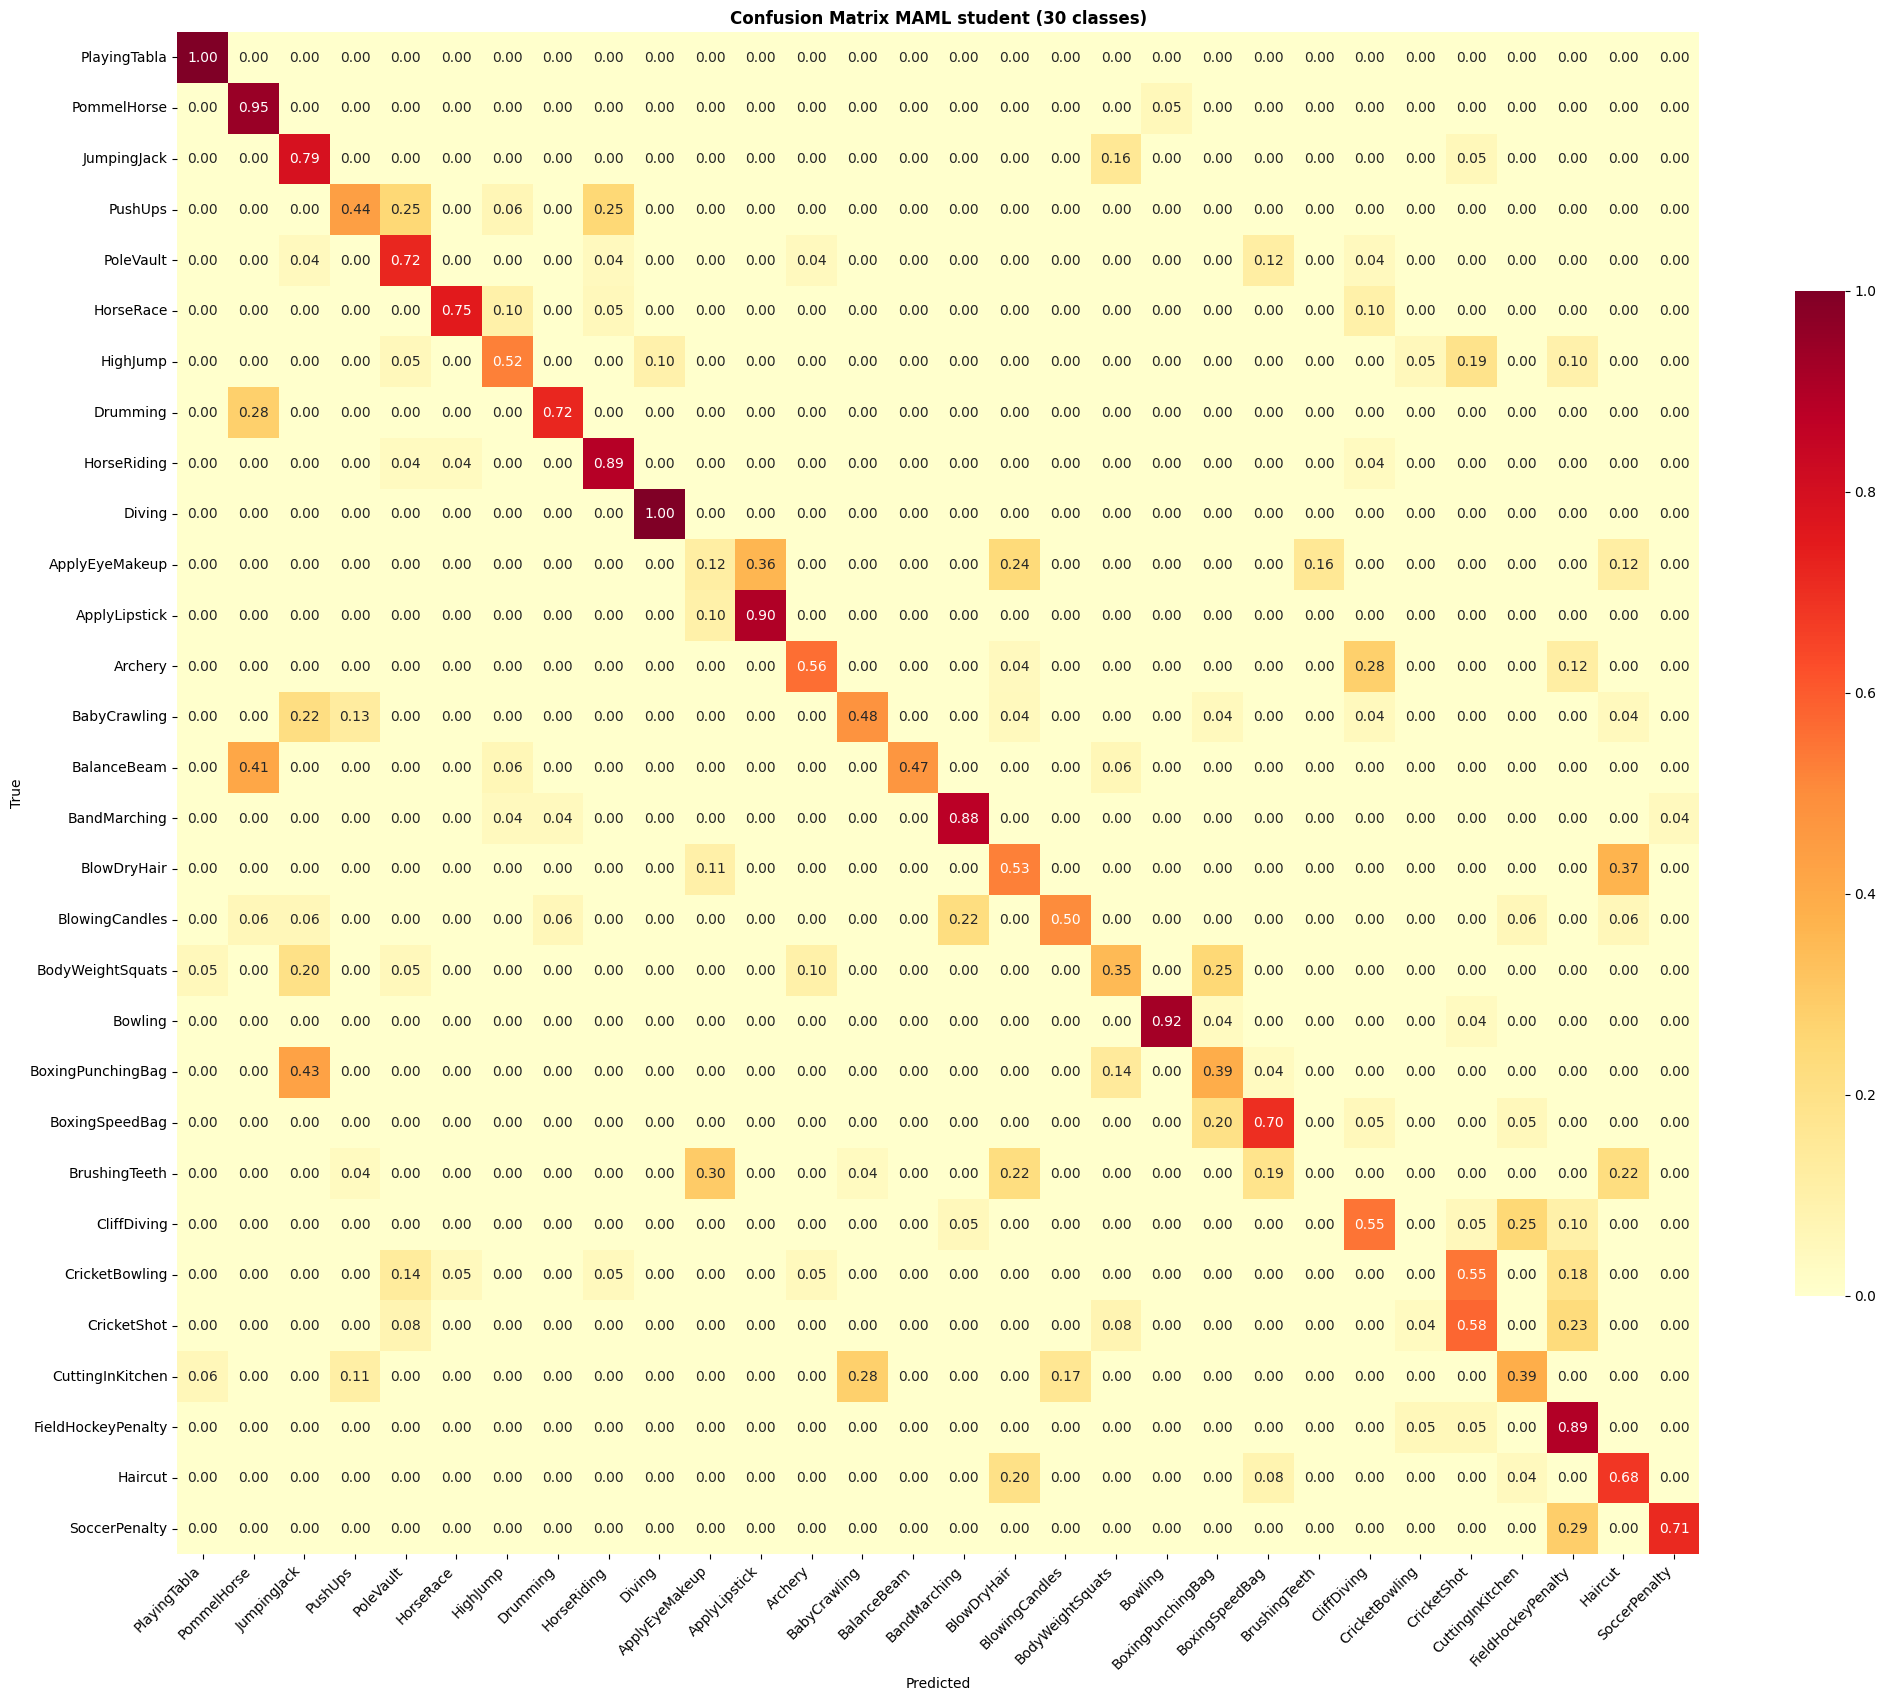

In [23]:
# test the MAML student on the 30 known classes, like the MAML notebook
maml_acc, maml_preds, maml_labels = test_model(maml_student, combined_test_loader2, device)
print(f"MAML student on 30 classes: {maml_acc:.4f}  (KD student was {student_acc:.4f})")
plot_confusion_matrix(maml_labels, maml_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="MAML student (30 classes)")
torch.cuda.empty_cache()

## **Part 5: Test on real YouTube videos**

Test the final pipeline on real YouTube videos: learn new sports from a few clips (MAML + replay).

This is what the MAML student was built for, and MAML + replay was the best method in the MAML study. Download videos of 5 sports that no model has seen, let each model learn them from 10 YouTube clips per sport, and test on two other videos of each sport. Replay of old UCF clips keeps the 30 known classes. The teacher (ResNet50) and the KD student are adapted the same way as references.

MAML is built to learn in a few quick updates, so the models learn with 1, 2, 3 or 5 passes over the clips: few passes = learning must be fast. The table then shows where meta-learning helps and where a plain student catches up.

YouTube can block downloads on Colab. A local video file path works in place of a link.

**Learn 5 new sports from a few YouTube clips (MAML + replay)**

Same learning rate and replay as the MAML study notebook, for all three models. The 5 new sports are the study's held-out exam sports: they are not among the 30 known classes and not among the meta-training sports (MAML never saw them). Each sport has 4 videos: the first two are for learning, the last two are only for testing (10 test videos in total).

In [24]:
# 10 clips per new sport; only the number of passes (epochs) changes between the runs below
YT_CLIPS = 10
YT_EPOCHS = [1, 2, 3, 5]
ADAPT_LR = 3e-4
REPLAY_PER_CLASS = 8

# free the ResNet50 replay buffer from Part 2 before the new clips come into RAM
buffer = None; gc.collect()

# 5 new sports (the study's exam sports), 4 videos each - the LAST TWO videos of each sport are the test videos
YT_NEW_VIDEOS = {
    "GolfSwing":        ["https://www.youtube.com/watch?v=P3YksJdejog",
                         "https://www.youtube.com/watch?v=9YuObuvGano",
                         "https://www.youtube.com/watch?v=esvEhCC9Crk",
                         "https://www.youtube.com/watch?v=1d0MhjE1Jzs"],
    "FrontCrawl":       ["https://www.youtube.com/watch?v=m3BsRGK9RSQ",
                         "https://www.youtube.com/shorts/E0wxcWAalF0",
                         "https://www.youtube.com/shorts/i5rTF46WzsY",
                         "https://www.youtube.com/watch?v=M_aAdpzZxGs"],
    "HammerThrow":      ["https://www.youtube.com/watch?v=-KMcZ5eSxqI",
                         "https://www.youtube.com/watch?v=0KEufjn_CfU",
                         "https://www.youtube.com/watch?v=mG-vO2y5XqI",
                         "https://www.youtube.com/watch?v=89beg0cOgMs"],
    "HandstandPushups": ["https://www.youtube.com/watch?v=9wIkPCS4Mbo",
                         "https://www.youtube.com/watch?v=0wDEO6shVjc",
                         "https://www.youtube.com/watch?v=APQhH9LwmuU",
                         "https://www.youtube.com/watch?v=gdhmNaZ7nAk"],
    "HandstandWalking": ["https://www.youtube.com/shorts/TkK883cIGDY",
                         "https://www.youtube.com/shorts/Po8DBkuC4M8",
                         "https://www.youtube.com/shorts/YLfHsvLjgjs",
                         "https://www.youtube.com/shorts/zpe45Xft69U"],
}
yt_new_classes = list(YT_NEW_VIDEOS)
yt_new_c2i     = {c: i for i, c in enumerate(ALL_CLASSES_LIST + yt_new_classes)}
n_yt_new       = len(yt_new_classes)
print(f"new sports: {yt_new_classes}")
print(f"overlap with the 30 known or the meta sports: {set(yt_new_classes) & (known | set(MAML_META))}")

new sports: ['GolfSwing', 'FrontCrawl', 'HammerThrow', 'HandstandPushups', 'HandstandWalking']
overlap with the 30 known or the meta sports: set()


Download the videos and cut each one into 10 clips.

In [25]:
yt_new_clips, yt_new_labels, yt_new_vids = download_youtube_clips(YT_NEW_VIDEOS, yt_new_c2i, clips_per_video=10)
print(f"downloaded {len(yt_new_clips)} clips from {len(yt_new_vids.unique())} videos")

  GolfSwing video 0: 10 clips
  GolfSwing video 1: 10 clips
  GolfSwing video 2: 10 clips
  GolfSwing video 3: 10 clips
  GolfSwing       : 4 usable video(s)
  FrontCrawl video 0: 10 clips
  FrontCrawl video 1: 10 clips
  FrontCrawl video 2: 10 clips
  FrontCrawl video 3: download failed - skipping
  FrontCrawl      : 3 usable video(s)
  HammerThrow video 0: 10 clips
  HammerThrow video 1: 10 clips
  HammerThrow video 2: 10 clips
  HammerThrow video 3: 10 clips
  HammerThrow     : 4 usable video(s)
  HandstandPushups video 0: 10 clips
  HandstandPushups video 1: 10 clips
  HandstandPushups video 2: 10 clips
  HandstandPushups video 3: 10 clips
  HandstandPushups: 4 usable video(s)
  HandstandWalking video 0: 10 clips
  HandstandWalking video 1: 10 clips
  HandstandWalking video 2: 10 clips
  HandstandWalking video 3: 10 clips
  HandstandWalking: 4 usable video(s)
downloaded 190 clips from 19 videos


Split by video: the last two videos of each sport are held out for testing, so no test clip comes from a video the student learned from.

In [26]:
adapt_x, adapt_y, yt_test_x, yt_test_y = video_disjoint_split(yt_new_clips, yt_new_labels, yt_new_vids, holdout_per_class=2)
yt_test_loader = DataLoader(TensorDataset(yt_test_x, yt_test_y), batch_size=cfg.BATCH_SIZE)
print("learn clips per sport:", torch.bincount(adapt_y - len(ALL_CLASSES_LIST), minlength=n_yt_new).tolist())
print("test clips per sport :", torch.bincount(yt_test_y - len(ALL_CLASSES_LIST), minlength=n_yt_new).tolist())

learn clips per sport: [20, 10, 20, 20, 20]
test clips per sport : [20, 20, 20, 20, 20]


Replay buffer: a few UCF clips of each of the 30 known classes, mixed into every batch so the student keeps them while it learns the new sports.

In [27]:
# keep REPLAY_PER_CLASS clips of every known class
set_seed(cfg.SEED)
yt_buffer = ReplayBuffer(max_size=REPLAY_PER_CLASS * len(ALL_CLASSES_LIST))
fill_buffer(yt_buffer, base_train_loader,  per_class=REPLAY_PER_CLASS)
fill_buffer(yt_buffer, task1_train_loader, per_class=REPLAY_PER_CLASS)
fill_buffer(yt_buffer, task2_train_loader, per_class=REPLAY_PER_CLASS)
print(f"replay buffer: {len(yt_buffer.data)} UCF clips ({REPLAY_PER_CLASS} per known class)")

replay buffer: 240 UCF clips (8 per known class)


The SAME 10 learning clips per sport for every model and every run (spread over the two learning videos), the same replay buffer, learning rate and seed. Only the number of passes over the clips changes (1, 2, 3 or 5 epochs). new = accuracy on the unseen test videos, old = accuracy kept on the 30 UCF classes.

In [28]:
sup_x, sup_y = spread_per_class(adapt_x, adapt_y, YT_CLIPS)
sup_loader   = DataLoader(TensorDataset(sup_x, sup_y), batch_size=cfg.BATCH_SIZE, shuffle=True)
UPDATES_PER_EPOCH = len(sup_loader)
print(f"{len(sup_x)} learning clips ({YT_CLIPS} per sport) -> {UPDATES_PER_EPOCH} updates per epoch")

50 learning clips (10 per sport) -> 13 updates per epoch


In [29]:
# 1 EPOCH - the fastest learning
set_seed(cfg.SEED)
_, teacher_e1_new, teacher_e1_old, _, _ = adapt_and_eval(copy.deepcopy(model), sup_loader, combined_test_loader2, yt_test_loader,
                                                         len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                         epochs=1, lr=ADAPT_LR, verbose=False, track=False)
gc.collect(); torch.cuda.empty_cache()
set_seed(cfg.SEED)
_, kd_e1_new, kd_e1_old, _, _ = adapt_and_eval(copy.deepcopy(student), sup_loader, combined_test_loader2, yt_test_loader,
                                               len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                               epochs=1, lr=ADAPT_LR, verbose=False, track=False)
set_seed(cfg.SEED)
_, maml_e1_new, maml_e1_old, _, _ = adapt_and_eval(copy.deepcopy(maml_student), sup_loader, combined_test_loader2, yt_test_loader,
                                                   len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                   epochs=1, lr=ADAPT_LR, verbose=False, track=False)
print(f"1 epoch  ({1 * UPDATES_PER_EPOCH} updates) | teacher + replay     : new {teacher_e1_new:.3f}  old {teacher_e1_old:.3f}")
print(f"1 epoch  ({1 * UPDATES_PER_EPOCH} updates) | KD student + replay  : new {kd_e1_new:.3f}  old {kd_e1_old:.3f}")
print(f"1 epoch  ({1 * UPDATES_PER_EPOCH} updates) | MAML student + replay: new {maml_e1_new:.3f}  old {maml_e1_old:.3f}")
torch.cuda.empty_cache()

1 epoch  (13 updates) | teacher + replay     : new 0.210  old 0.768
1 epoch  (13 updates) | KD student + replay  : new 0.000  old 0.583
1 epoch  (13 updates) | MAML student + replay: new 0.160  old 0.545


In [30]:
# 2 EPOCHS
set_seed(cfg.SEED)
_, teacher_e2_new, teacher_e2_old, _, _ = adapt_and_eval(copy.deepcopy(model), sup_loader, combined_test_loader2, yt_test_loader,
                                                         len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                         epochs=2, lr=ADAPT_LR, verbose=False, track=False)
gc.collect(); torch.cuda.empty_cache()
set_seed(cfg.SEED)
_, kd_e2_new, kd_e2_old, _, _ = adapt_and_eval(copy.deepcopy(student), sup_loader, combined_test_loader2, yt_test_loader,
                                               len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                               epochs=2, lr=ADAPT_LR, verbose=False, track=False)
set_seed(cfg.SEED)
_, maml_e2_new, maml_e2_old, _, _ = adapt_and_eval(copy.deepcopy(maml_student), sup_loader, combined_test_loader2, yt_test_loader,
                                                   len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                   epochs=2, lr=ADAPT_LR, verbose=False, track=False)
print(f"2 epochs ({2 * UPDATES_PER_EPOCH} updates) | teacher + replay     : new {teacher_e2_new:.3f}  old {teacher_e2_old:.3f}")
print(f"2 epochs ({2 * UPDATES_PER_EPOCH} updates) | KD student + replay  : new {kd_e2_new:.3f}  old {kd_e2_old:.3f}")
print(f"2 epochs ({2 * UPDATES_PER_EPOCH} updates) | MAML student + replay: new {maml_e2_new:.3f}  old {maml_e2_old:.3f}")
torch.cuda.empty_cache()

2 epochs (26 updates) | teacher + replay     : new 0.370  old 0.773
2 epochs (26 updates) | KD student + replay  : new 0.230  old 0.644
2 epochs (26 updates) | MAML student + replay: new 0.360  old 0.544


In [31]:
# 3 EPOCHS
set_seed(cfg.SEED)
_, teacher_e3_new, teacher_e3_old, _, _ = adapt_and_eval(copy.deepcopy(model), sup_loader, combined_test_loader2, yt_test_loader,
                                                         len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                         epochs=3, lr=ADAPT_LR, verbose=False, track=False)
gc.collect(); torch.cuda.empty_cache()
set_seed(cfg.SEED)
_, kd_e3_new, kd_e3_old, _, _ = adapt_and_eval(copy.deepcopy(student), sup_loader, combined_test_loader2, yt_test_loader,
                                               len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                               epochs=3, lr=ADAPT_LR, verbose=False, track=False)
set_seed(cfg.SEED)
_, maml_e3_new, maml_e3_old, _, _ = adapt_and_eval(copy.deepcopy(maml_student), sup_loader, combined_test_loader2, yt_test_loader,
                                                   len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                   epochs=3, lr=ADAPT_LR, verbose=False, track=False)
print(f"3 epochs ({3 * UPDATES_PER_EPOCH} updates) | teacher + replay     : new {teacher_e3_new:.3f}  old {teacher_e3_old:.3f}")
print(f"3 epochs ({3 * UPDATES_PER_EPOCH} updates) | KD student + replay  : new {kd_e3_new:.3f}  old {kd_e3_old:.3f}")
print(f"3 epochs ({3 * UPDATES_PER_EPOCH} updates) | MAML student + replay: new {maml_e3_new:.3f}  old {maml_e3_old:.3f}")
torch.cuda.empty_cache()

3 epochs (39 updates) | teacher + replay     : new 0.490  old 0.744
3 epochs (39 updates) | KD student + replay  : new 0.420  old 0.614
3 epochs (39 updates) | MAML student + replay: new 0.470  old 0.533


In [32]:
# 5 EPOCHS - the study's budget (keep the MAML model to look at its predictions)
set_seed(cfg.SEED)
_, teacher_e5_new, teacher_e5_old, _, _ = adapt_and_eval(copy.deepcopy(model), sup_loader, combined_test_loader2, yt_test_loader,
                                                         len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                         epochs=5, lr=ADAPT_LR, verbose=False, track=False)
gc.collect(); torch.cuda.empty_cache()
set_seed(cfg.SEED)
_, kd_e5_new, kd_e5_old, _, _ = adapt_and_eval(copy.deepcopy(student), sup_loader, combined_test_loader2, yt_test_loader,
                                               len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                               epochs=5, lr=ADAPT_LR, verbose=False, track=False)
set_seed(cfg.SEED)
maml_e5_model, maml_e5_new, maml_e5_old, _, _ = adapt_and_eval(copy.deepcopy(maml_student), sup_loader, combined_test_loader2, yt_test_loader,
                                                               len(ALL_CLASSES_LIST), n_yt_new, device, buffer=yt_buffer,
                                                               epochs=5, lr=ADAPT_LR, verbose=False, track=False)
print(f"5 epochs ({5 * UPDATES_PER_EPOCH} updates) | teacher + replay     : new {teacher_e5_new:.3f}  old {teacher_e5_old:.3f}")
print(f"5 epochs ({5 * UPDATES_PER_EPOCH} updates) | KD student + replay  : new {kd_e5_new:.3f}  old {kd_e5_old:.3f}")
print(f"5 epochs ({5 * UPDATES_PER_EPOCH} updates) | MAML student + replay: new {maml_e5_new:.3f}  old {maml_e5_old:.3f}")
torch.cuda.empty_cache()

5 epochs (65 updates) | teacher + replay     : new 0.350  old 0.776
5 epochs (65 updates) | KD student + replay  : new 0.570  old 0.586
5 epochs (65 updates) | MAML student + replay: new 0.470  old 0.542


Compare the three models. harmonic is the balance between new and old accuracy (the metric of the MAML study): it is high only when a model learns the new sports AND keeps the old classes.

In [33]:
yt_rows = [
    {"epochs": 1, "updates": 1 * UPDATES_PER_EPOCH, "method": "teacher + replay",      "youtube_new_acc": teacher_e1_new, "ucf_old_acc": teacher_e1_old},
    {"epochs": 1, "updates": 1 * UPDATES_PER_EPOCH, "method": "KD student + replay",   "youtube_new_acc": kd_e1_new, "ucf_old_acc": kd_e1_old},
    {"epochs": 1, "updates": 1 * UPDATES_PER_EPOCH, "method": "MAML student + replay", "youtube_new_acc": maml_e1_new, "ucf_old_acc": maml_e1_old},
    {"epochs": 2, "updates": 2 * UPDATES_PER_EPOCH, "method": "teacher + replay",      "youtube_new_acc": teacher_e2_new, "ucf_old_acc": teacher_e2_old},
    {"epochs": 2, "updates": 2 * UPDATES_PER_EPOCH, "method": "KD student + replay",   "youtube_new_acc": kd_e2_new, "ucf_old_acc": kd_e2_old},
    {"epochs": 2, "updates": 2 * UPDATES_PER_EPOCH, "method": "MAML student + replay", "youtube_new_acc": maml_e2_new, "ucf_old_acc": maml_e2_old},
    {"epochs": 3, "updates": 3 * UPDATES_PER_EPOCH, "method": "teacher + replay",      "youtube_new_acc": teacher_e3_new, "ucf_old_acc": teacher_e3_old},
    {"epochs": 3, "updates": 3 * UPDATES_PER_EPOCH, "method": "KD student + replay",   "youtube_new_acc": kd_e3_new, "ucf_old_acc": kd_e3_old},
    {"epochs": 3, "updates": 3 * UPDATES_PER_EPOCH, "method": "MAML student + replay", "youtube_new_acc": maml_e3_new, "ucf_old_acc": maml_e3_old},
    {"epochs": 5, "updates": 5 * UPDATES_PER_EPOCH, "method": "teacher + replay",      "youtube_new_acc": teacher_e5_new, "ucf_old_acc": teacher_e5_old},
    {"epochs": 5, "updates": 5 * UPDATES_PER_EPOCH, "method": "KD student + replay",   "youtube_new_acc": kd_e5_new, "ucf_old_acc": kd_e5_old},
    {"epochs": 5, "updates": 5 * UPDATES_PER_EPOCH, "method": "MAML student + replay", "youtube_new_acc": maml_e5_new, "ucf_old_acc": maml_e5_old},
]
yt_df = pd.DataFrame(yt_rows)
yt_df["harmonic"] = 2 * yt_df.youtube_new_acc * yt_df.ucf_old_acc / (yt_df.youtube_new_acc + yt_df.ucf_old_acc)
print(yt_df.round(3).to_string(index=False))

 epochs  updates                method  youtube_new_acc  ucf_old_acc  harmonic
      1       13      teacher + replay             0.21        0.768     0.330
      1       13   KD student + replay             0.00        0.583     0.000
      1       13 MAML student + replay             0.16        0.545     0.247
      2       26      teacher + replay             0.37        0.773     0.500
      2       26   KD student + replay             0.23        0.644     0.339
      2       26 MAML student + replay             0.36        0.544     0.433
      3       39      teacher + replay             0.49        0.744     0.591
      3       39   KD student + replay             0.42        0.614     0.499
      3       39 MAML student + replay             0.47        0.533     0.499
      5       65      teacher + replay             0.35        0.776     0.482
      5       65   KD student + replay             0.57        0.586     0.578
      5       65 MAML student + replay             0

Accuracy on the unseen YouTube videos as the number of updates grows.

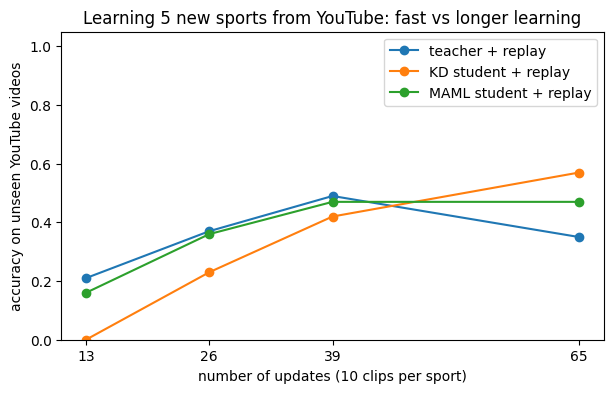

In [34]:
yt_updates = [1 * UPDATES_PER_EPOCH, 2 * UPDATES_PER_EPOCH, 3 * UPDATES_PER_EPOCH, 5 * UPDATES_PER_EPOCH]
plt.figure(figsize=(7, 4))
plt.plot(yt_updates, [teacher_e1_new, teacher_e2_new, teacher_e3_new, teacher_e5_new], marker="o", label="teacher + replay")
plt.plot(yt_updates, [kd_e1_new, kd_e2_new, kd_e3_new, kd_e5_new], marker="o", label="KD student + replay")
plt.plot(yt_updates, [maml_e1_new, maml_e2_new, maml_e3_new, maml_e5_new], marker="o", label="MAML student + replay")
plt.xticks(yt_updates); plt.ylim(0, 1.05); plt.legend()
plt.xlabel("number of updates (10 clips per sport)"); plt.ylabel("accuracy on unseen YouTube videos")
plt.title("Learning 5 new sports from YouTube: fast vs longer learning")
plt.show()

What the MAML student (after 5 epochs) predicts on the unseen test videos (rows are the true sport, columns the predicted class).

In [43]:
#_, maml_e5_preds, maml_e5_labels = test_model(maml_e5_model, yt_test_loader, device)
#del maml_e5_model; torch.cuda.empty_cache()

## **Summary**

In [38]:
print("ULAL pipeline results")
print(f"  base ResNet50 (10 classes)  : {base_acc:.4f}")
print(f"  replay CL (30 classes)      : {cl_acc:.4f}")
print(f"  MobileNet student (cosine)  : {student_acc:.4f}  ({teacher_params/student_params:.0f}x smaller)")
print(f"  MAML student (30 classes)   : {maml_acc:.4f}")
print(f"  YouTube new sports, {YT_CLIPS} clips/sport, new accuracy (all + replay):")
print(f"    1 epoch  ({1 * UPDATES_PER_EPOCH} updates): teacher {teacher_e1_new:.3f} | KD {kd_e1_new:.3f} | MAML {maml_e1_new:.3f}")
print(f"    2 epochs ({2 * UPDATES_PER_EPOCH} updates): teacher {teacher_e2_new:.3f} | KD {kd_e2_new:.3f} | MAML {maml_e2_new:.3f}")
print(f"    3 epochs ({3 * UPDATES_PER_EPOCH} updates): teacher {teacher_e3_new:.3f} | KD {kd_e3_new:.3f} | MAML {maml_e3_new:.3f}")
print(f"    5 epochs ({5 * UPDATES_PER_EPOCH} updates): teacher {teacher_e5_new:.3f} | KD {kd_e5_new:.3f} | MAML {maml_e5_new:.3f}")

ULAL pipeline results
  base ResNet50 (10 classes)  : 0.9387
  replay CL (30 classes)      : 0.7969
  MobileNet student (cosine)  : 0.6718  (14x smaller)
  MAML student (30 classes)   : 0.6076
  YouTube new sports, 10 clips/sport, new accuracy (all + replay):
    1 epoch  (13 updates): teacher 0.210 | KD 0.000 | MAML 0.160
    2 epochs (26 updates): teacher 0.370 | KD 0.230 | MAML 0.360
    3 epochs (39 updates): teacher 0.490 | KD 0.420 | MAML 0.470
    5 epochs (65 updates): teacher 0.350 | KD 0.570 | MAML 0.470


Create a .json file with final results.

In [39]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"base_acc": base_acc, "continual_acc": cl_acc, "student_acc": student_acc,
           "maml_student_acc": maml_acc,
           "youtube_new_sports": yt_df.round(4).to_dict("records"),
           "teacher_params": teacher_params, "student_params": student_params,
           "maml_curve": hist_maml["query_accs"]}
with open(f"{cfg.RESULTS_DIR}/ulal_summary.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/ulal_summary.json")

saved -> /content/drive/MyDrive/apai/results/ulal_summary.json
